# 实验一参考答案：航天贸易数据处理全流程

> 对应讲次：第1讲 Python 数据处理 × Vibe Coding
>
> 数据集：航天进出口额.xlsx（76行×29列，42个国家/地区，2022-2023共24个月）
>
> 本参考答案展示完整的 Vibe Coding 工作流程，包括 Prompt 设计和 Diff 审查示范

## 任务1：数据加载与探索性分析（15分）

### Prompt 设计

```
【氛围段】我拿到了一份航天进出口贸易的 Excel 数据，需要先全面了解数据的基本情况。

【约束段】请帮我：
1. 用 pd.read_excel 读取"航天进出口额.xlsx"
2. 打印前5行、info()、shape、describe()
3. 在代码注释中说明每步的观察要点
4. 变量名英文，注释中文
```

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 读取数据
df = pd.read_excel('../实验一/航天进出口额.xlsx', sheet_name='Sheet0')

# 基本信息
print(f"数据形状: {df.shape}")
print(f"行数={df.shape[0]}, 列数={df.shape[1]}")
print()

# 前5行预览
print("=== 前5行预览 ===")
print(df.head())

数据形状: (76, 29)
行数=76, 列数=29

=== 前5行预览 ===
                                    指标 进出口  地区 频度  单位  2022-01  2022-02  \
0    进口额(人民币)_(HS88章)航空器、航天器及其零件_印度_当期  进口  全国  月  万元   288.13   601.83   
1  进口额(人民币)_(HS88章)航空器、航天器及其零件_中国香港_当期  进口  全国  月  万元     5.54     1.52   
2    进口额(人民币)_(HS88章)航空器、航天器及其零件_日本_当期  进口  全国  月  万元  2653.87  1473.53   
3  进口额(人民币)_(HS88章)航空器、航天器及其零件_马来西亚_当期  进口  全国  月  万元  1668.97   852.08   
4  进口额(人民币)_(HS88章)航空器、航天器及其零件_中国台湾_当期  进口  全国  月  万元  1189.64   421.17   

   2022-03  2022-04  2022-05  ...  2023-03  2023-04  2023-05  2023-06  \
0   277.40    937.0   460.15  ...   558.96   603.73   309.91   240.31   
1      NaN      NaN     0.92  ...    14.58     2.05     4.38     0.14   
2  1739.32    690.0  2964.17  ...  1968.32  4095.97  1971.03  1433.03   
3  1181.90    851.0   796.75  ...   622.12   444.11   969.27  1039.92   
4   955.36    316.0  1415.12  ...  1147.03  1007.53  1309.67  1603.82   

   2023-07  2023-08  2023-09  2023-10  2023-11  2023-12  
0   164.4

In [2]:
# 数据类型与非空计数
print("=== 数据信息 ===")
print(df.info())

=== 数据信息 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 29 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   指标       76 non-null     object 
 1   进出口      76 non-null     object 
 2   地区       76 non-null     object 
 3   频度       76 non-null     object 
 4   单位       76 non-null     object 
 5   2022-01  71 non-null     float64
 6   2022-02  69 non-null     float64
 7   2022-03  72 non-null     float64
 8   2022-04  70 non-null     float64
 9   2022-05  72 non-null     float64
 10  2022-06  73 non-null     float64
 11  2022-07  73 non-null     float64
 12  2022-08  69 non-null     float64
 13  2022-09  71 non-null     float64
 14  2022-10  71 non-null     float64
 15  2022-11  71 non-null     float64
 16  2022-12  71 non-null     float64
 17  2023-01  69 non-null     float64
 18  2023-02  71 non-null     float64
 19  2023-03  71 non-null     float64
 20  2023-04  73 non-null     float64
 21  2023-

In [3]:
# 数值列描述性统计
print("=== 描述性统计（数值列前6列）===")
numeric_cols = df.select_dtypes(include='number').columns
print(df[numeric_cols[:6]].describe())

=== 描述性统计（数值列前6列）===
             2022-01        2022-02        2022-03        2022-04  \
count      71.000000      69.000000      72.000000      70.000000   
mean    17148.135352   12346.128406   11697.702917   13846.985714   
std     53448.919933   44166.184862   36789.025862   42247.334262   
min         1.380000       0.480000       0.910000       0.000000   
25%       136.885000     103.720000      74.627500     146.250000   
50%       882.020000     852.080000     931.795000     958.500000   
75%      3375.275000    4763.810000    2423.985000    3389.250000   
max    290765.470000  301856.990000  224143.030000  243179.000000   

            2022-05        2022-06  
count      72.00000      73.000000  
mean    11709.65125    8998.328767  
std     33113.71739   24106.199389  
min         0.06000       2.000000  
25%       275.65750     228.000000  
50%      1396.71000    1018.000000  
75%      3227.84000    4464.000000  
max    175650.31000  145764.000000  


### 数据结构说明

该数据集包含76行×29列。第一列为复合指标列（格式如"进口额(人民币)_(HS88章)航空器、航天器及其零件_日本_当期"），包含贸易方向、商品类别、国家和时间周期信息。其余28列为月度贸易额数值（2022年1月至2023年12月共24个月度数据列，另有若干汇总列）。数据粒度为"国家×月度"，覆盖约42个国家/地区的航天器进出口贸易额，单位为万元人民币，含自然缺失值。

### Diff 审查记录

| 检查维度 | 是否通过 | 说明 |
|----------|:--------:|------|
| 结构 | 通过 | pandas 导入正确，变量名规范 |
| 逻辑 | 通过 | read_excel 指定了 sheet_name |
| 边界 | 通过 | 无编码问题（xlsx 不涉及 encoding） |

## 任务2：指标列解析与数据清洗（30分）

### Round 1 Prompt：列拆分

```
【氛围段】数据集的第一列是复合格式（含方向、国家等信息），我需要拆开以便后续分组分析。

【约束段】请实现：
1. 打印第一列的前3个值，观察命名规则
2. 从中提取"贸易方向"（进口/出口）和"国家/地区"
3. 添加为新列，验证结果
4. 变量名英文，注释中文
```

In [4]:
# 观察指标列命名规则
first_col = df.columns[0]
print(f"指标列名: {first_col[:20]}...")
print()
print("前3个指标值:")
for i, val in enumerate(df[first_col].head(3)):
    print(f"  [{i}] {val}")

指标列名: 指标...

前3个指标值:
  [0] 进口额(人民币)_(HS88章)航空器、航天器及其零件_印度_当期
  [1] 进口额(人民币)_(HS88章)航空器、航天器及其零件_中国香港_当期
  [2] 进口额(人民币)_(HS88章)航空器、航天器及其零件_日本_当期


In [5]:
# 解析方向和国家
# 规则：含"进口"则为进口，否则为出口；国家在倒数第二个下划线段
df['方向'] = df[first_col].apply(lambda x: '进口' if '进口' in str(x) else '出口')
df['国家'] = df[first_col].apply(lambda x: str(x).split('_')[-2] if '_' in str(x) else '未知')

print("=== 解析结果验证 ===")
print(f"方向分布:\n{df['方向'].value_counts()}")
print()
print(f"国家示例: {df['国家'].unique()[:10]}")
print(f"共{df['国家'].nunique()}个国家/地区")

=== 解析结果验证 ===
方向分布:
方向
出口    41
进口    35
Name: count, dtype: int64

国家示例: ['印度' '中国香港' '日本' '马来西亚' '中国台湾' '菲律宾' '新加坡' '韩国' '泰国' '土耳其']
共42个国家/地区


### Round 2 Prompt：缺失值处理

```
【氛围段】数据中有自然缺失值（部分国家某些月份无贸易记录），需要分析并处理。

【约束段】请实现：
1. 统计每列缺失值数量和缺失率
2. 选用中位数填充（理由：贸易数据通常右偏，中位数比均值更稳健）
3. 填充后验证无缺失
4. 打印填充前后对比
```

In [6]:
# 识别月度数值列：只保留 YYYY-MM 格式的月份列，排除进出口、地区、频度、单位等文本元数据
month_cols = df.columns[df.columns.astype(str).str.fullmatch(r'\d{4}-\d{2}')].tolist()
if not month_cols:
    raise ValueError('未识别到 YYYY-MM 格式的月度数据列，请检查 Excel 表头。')
df[month_cols] = df[month_cols].apply(pd.to_numeric, errors='coerce')
print(f"数值列数: {len(month_cols)}")
print()

# 缺失值统计
missing_info = pd.DataFrame({
    '缺失数': df[month_cols].isnull().sum(),
    '缺失率%': (df[month_cols].isnull().sum() / len(df) * 100).round(2)
})
missing_info = missing_info[missing_info['缺失数'] > 0].sort_values('缺失率%', ascending=False)
print(f"=== 含缺失值的列（共{len(missing_info)}列）===")
print(missing_info)

数值列数: 24

=== 含缺失值的列（共23列）===
         缺失数  缺失率%
2023-01    7  9.21
2022-08    7  9.21
2022-02    7  9.21
2023-11    6  7.89
2022-04    6  7.89
2022-11    5  6.58
2023-07    5  6.58
2023-03    5  6.58
2023-02    5  6.58
2022-01    5  6.58
2022-10    5  6.58
2022-09    5  6.58
2022-12    5  6.58
2022-05    4  5.26
2022-03    4  5.26
2023-09    4  5.26
2022-07    3  3.95
2022-06    3  3.95
2023-04    3  3.95
2023-05    3  3.95
2023-06    3  3.95
2023-08    2  2.63
2023-10    2  2.63


In [7]:
# 缺失值填充：中位数策略
# 理由：贸易额数据通常右偏（少数大额交易拉高均值），中位数更能代表"典型值"
fill_count = df[month_cols].isnull().sum().sum()
print(f"填充前总缺失: {fill_count} 个")

for col in month_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

remaining = df[month_cols].isnull().sum().sum()
print(f"填充后总缺失: {remaining} 个")
print(f"共填充: {fill_count - remaining} 个缺失值")

填充前总缺失: 104 个
填充后总缺失: 0 个
共填充: 104 个缺失值


### Round 3 Prompt：异常值检测

```
【氛围段】数据填充完毕，现在需要检测是否存在异常值（极端高或极端低的贸易额）。

【约束段】请实现：
1. 选取前3个月度列
2. 分别用 IQR 法和 Z-score 法检测异常值
3. 输出检测报告：列名、方法、异常值数量、异常值示例
4. 用 scipy.stats.zscore，阈值设为3
```

In [8]:
# 异常值检测：选取前3个月度列
test_cols = month_cols[:3]
print("=== 异常值检测报告 ===")
print()

for col in test_cols:
    values = df[col].dropna()

    # IQR 法
    Q1, Q3 = values.quantile(0.25), values.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers_iqr = values[(values < lower) | (values > upper)]

    # Z-score 法
    z = np.abs(stats.zscore(values))
    outliers_z = values[z > 3]

    print(f"列: {col}")
    print(f"  IQR法: 范围[{lower:.1f}, {upper:.1f}], 异常值{len(outliers_iqr)}个")
    if len(outliers_iqr) > 0:
        print(f"    示例: {outliers_iqr.values[:3]}")
    print(f"  Z-score法(>3): 异常值{len(outliers_z)}个")
    if len(outliers_z) > 0:
        print(f"    示例: {outliers_z.values[:3]}")
    print()

=== 异常值检测报告 ===

列: 2022-01
  IQR法: 范围[-4450.9, 7860.3], 异常值13个
    示例: [ 17830.64 173784.18 110793.24]
  Z-score法(>3): 异常值4个
    示例: [173784.18 222108.98 290765.47]

列: 2022-02
  IQR法: 范围[-4535.5, 7853.5], 异常值10个
    示例: [177434.85 116927.32   8789.3 ]
  Z-score法(>3): 异常值2个
    示例: [177434.85 301856.99]

列: 2022-03
  IQR法: 范围[-3079.7, 5354.9], 异常值12个
    示例: [  9072.58 100714.11 118682.46]
  Z-score法(>3): 异常值3个
    示例: [118682.46 139219.94 224143.03]



### Diff 审查记录

| 检查维度 | 发现 | 处理 |
|----------|------|------|
| 结构 | scipy.stats 需单独导入 | 已在开头导入 |
| 逻辑 | split('_') 对部分国家名含下划线可能出错 | 检查结果，用倒数第二段更稳健 |
| 边界 | 全NaN列 fillna(median) 会填入 NaN | 检查确认无全空列 |

## 任务3：分组聚合与深度统计（30分）

### Prompt：进口 Top10 + 可视化

```
【氛围段】我已完成数据清洗，现在想深入分析各国航天贸易的规模排名和变化规律。

【约束段】请实现：
1. 筛选进口数据，计算每国年度合计，取 Top10 画条形图
2. 取 Top3 国家的24个月数据画折线图
3. 计算每国进口额标准差和变异系数，取波动 Top5
4. Top10 国家月度进口额的相关系数矩阵，找 >0.7 的国家对
每步独立 cell，图表加中文标题和标签。
```

In [9]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.sans-serif': ['Arial Unicode MS', 'SimHei', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'figure.dpi': 100,
    'savefig.dpi': 300,
})

# 计算年度合计
df['年度合计'] = df[month_cols].sum(axis=1)

# 筛选进口数据
df_import = df[df['方向'] == '进口'].copy()
print(f"进口数据: {len(df_import)} 行")

# Top10 进口国
top10 = df_import.nlargest(10, '年度合计')[['国家', '年度合计']]
print("\n=== 进口额 Top10 国家 ===")
print(top10.to_string(index=False))

进口数据: 35 行

=== 进口额 Top10 国家 ===
 国家       年度合计
 欧盟 9323854.78
 法国 5203221.11
 美国 5061660.21
 德国 3820897.37
加拿大  558497.86
 英国  266853.18
俄罗斯  164357.63
意大利  126055.40
西班牙   96361.38
 韩国   82467.32


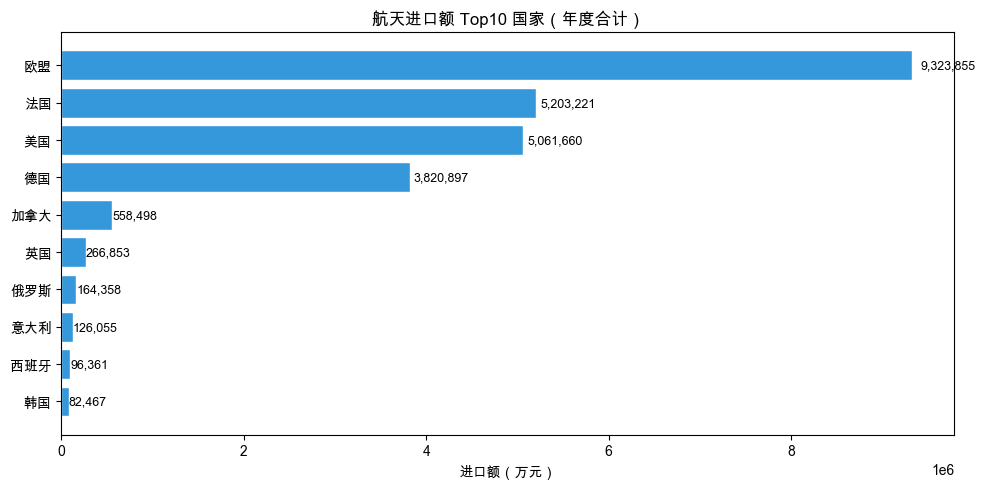

In [11]:
# Top10 条形图
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10['国家'][::-1], top10['年度合计'][::-1], color='#3498DB', edgecolor='white')
ax.set_title('航天进口额 Top10 国家（年度合计）')
ax.set_xlabel('进口额（万元）')
for i, v in enumerate(top10['年度合计'][::-1]):
    ax.text(v + v*0.01, i, f'{v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../output/top10_import.png', dpi=300, bbox_inches='tight')
plt.show()

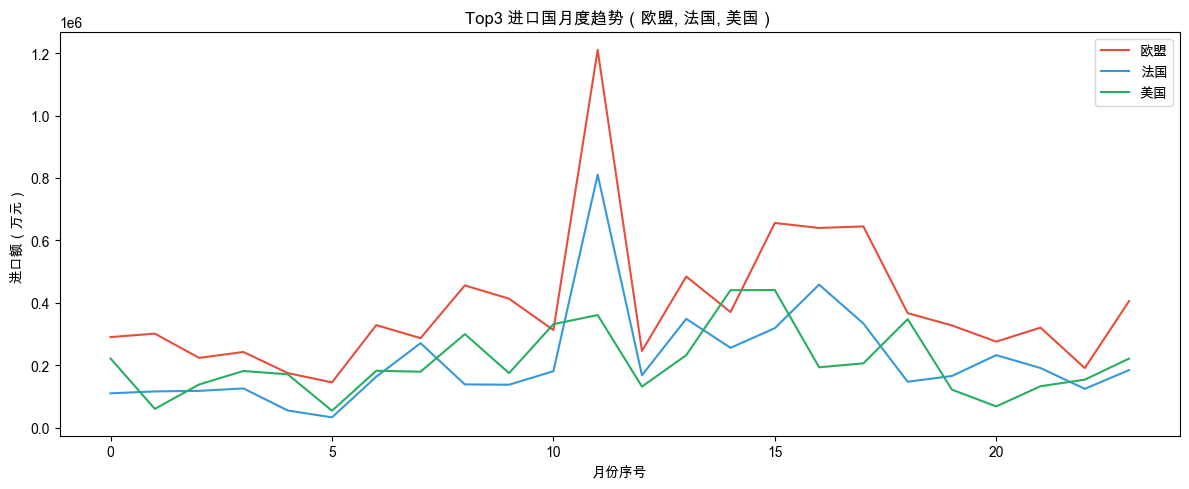

In [13]:
# Top3 国家月度趋势
top3_countries = top10['国家'].head(3).tolist()
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#E74C3C', '#3498DB', '#27AE60']
for country, color in zip(top3_countries, colors):
    row = df_import[df_import['国家'] == country]
    if len(row) > 0:
        values = row[month_cols].values.flatten()
        ax.plot(range(len(month_cols)), values, label=country, color=color, linewidth=1.5)

ax.set_title(f'Top3 进口国月度趋势（{", ".join(top3_countries)}）')
ax.set_xlabel('月份序号')
ax.set_ylabel('进口额（万元）')
ax.legend()
plt.tight_layout()
plt.savefig('../output/top3_trend.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# 波动性分析：标准差与变异系数
df_import['月标准差'] = df_import[month_cols].std(axis=1)
df_import['月均值'] = df_import[month_cols].mean(axis=1)
df_import['变异系数'] = df_import['月标准差'] / df_import['月均值'].replace(0, np.nan)

volatility_top5 = df_import.nlargest(5, '变异系数')[['国家', '月标准差', '月均值', '变异系数']]
print("=== 波动性 Top5（按变异系数）===")
print(volatility_top5.to_string(index=False))

=== 波动性 Top5（按变异系数）===
  国家         月标准差          月均值     变异系数
  瑞士  2586.536323   919.769583 2.812157
  瑞典   477.696330   217.781667 2.193464
中国香港   593.515737   292.271458 2.030700
 俄罗斯 10603.044669  6848.234583 1.548289
 加拿大 36007.245487 23270.744167 1.547318


In [15]:
# 相关性分析：Top10 国家月度进口额
top10_countries = top10['国家'].tolist()
corr_data = {}
for country in top10_countries:
    row = df_import[df_import['国家'] == country]
    if len(row) > 0:
        corr_data[country] = row[month_cols].values.flatten()

corr_df = pd.DataFrame(corr_data)
corr_matrix = corr_df.corr()

# 找出高相关国家对
print("=== 高相关国家对（|r| > 0.7）===")
high_corr_pairs = []
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append((corr_matrix.index[i], corr_matrix.columns[j], r))

if high_corr_pairs:
    for c1, c2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
        print(f"  {c1} ↔ {c2}: r = {r:.4f}")
else:
    print("  未发现 |r| > 0.7 的国家对")

=== 高相关国家对（|r| > 0.7）===
  欧盟 ↔ 法国: r = 0.9256
  欧盟 ↔ 德国: r = 0.7640


## 任务4：AI 辅助综合分析（25分）

### 自选问题：哪些国家的进出口存在显著不对称（贸易逆差/顺差）？

选择理由：贸易平衡是国际贸易分析的核心问题，能综合运用筛选、分组、聚合、可视化等技能。

### Round 1 Prompt

```
【氛围段】我想了解各国航天贸易是否平衡，看看哪些国家对中国有大额顺差或逆差。

【约束段】计算每个国家的进口总额和出口总额，求差值（进口-出口），按差值排序输出。
```

**审查发现**：代码没有处理缺失值就做了求和，可能导致结果偏小。

In [16]:
# Round 1：计算贸易差额
df_export = df[df['方向'] == '出口'].copy()
df_export['年度合计'] = df_export[month_cols].sum(axis=1)

# 按国家汇总进出口
import_by_country = df_import.groupby('国家')['年度合计'].sum().rename('进口总额')
export_by_country = df_export.groupby('国家')['年度合计'].sum().rename('出口总额')

# 合并计算差额
balance = pd.concat([import_by_country, export_by_country], axis=1).fillna(0)
balance['贸易差额'] = balance['进口总额'] - balance['出口总额']
balance['类型'] = balance['贸易差额'].apply(lambda x: '逆差(进口>出口)' if x > 0 else '顺差(出口>进口)')
balance = balance.sort_values('贸易差额', ascending=False)

print("=== 贸易差额排名（前10）===")
print(balance.head(10).to_string())

=== 贸易差额排名（前10）===
            进口总额        出口总额         贸易差额         类型
国家                                                  
欧盟   9323854.780  2646132.68  6677722.100  逆差(进口>出口)
法国   5203221.110   510540.44  4692680.670  逆差(进口>出口)
德国   3820897.370   386227.92  3434669.450  逆差(进口>出口)
美国   5061660.210  1665301.67  3396358.540  逆差(进口>出口)
加拿大   558497.860   275464.70   283033.160  逆差(进口>出口)
意大利   126055.400    66096.56    59958.840  逆差(进口>出口)
乌克兰    22416.345        0.00    22416.345  逆差(进口>出口)
芬兰     31058.990     8653.55    22405.440  逆差(进口>出口)
智利     34085.590    17247.17    16838.420  逆差(进口>出口)
奥地利    23010.080    20232.26     2777.820  逆差(进口>出口)


### Round 2 Prompt

```
【氛围段】数值结果出来了，但缺少直观展示。需要可视化来突出逆差和顺差的对比。

【约束段】对 Top10 贸易逆差和 Top10 贸易顺差国家画水平条形图：
- 红色表示逆差（进口>出口），蓝色表示顺差
- 加数值标注
- 中文标题
```

**审查发现**：逻辑正确，但建议加零线增强可读性。

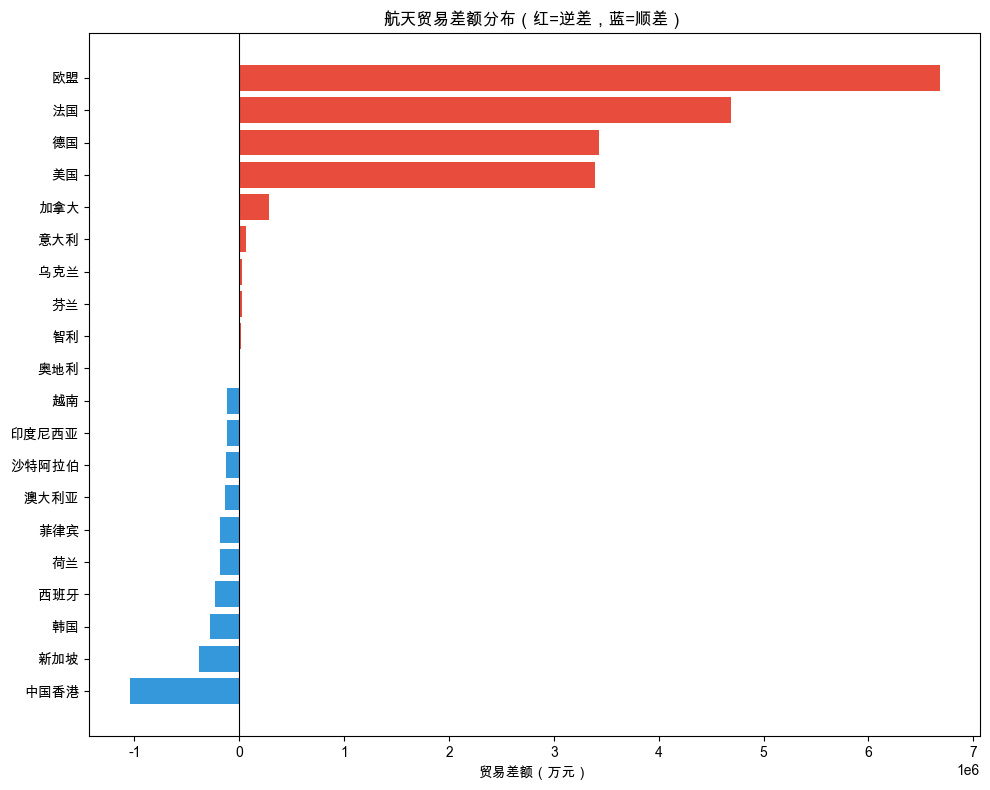

In [18]:
# Round 2：可视化贸易差额
top_deficit = balance.nlargest(10, '贸易差额')  # 逆差最大
top_surplus = balance.nsmallest(10, '贸易差额')  # 顺差最大
plot_data = pd.concat([top_deficit, top_surplus]).sort_values('贸易差额')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E74C3C' if v > 0 else '#3498DB' for v in plot_data['贸易差额']]
bars = ax.barh(range(len(plot_data)), plot_data['贸易差额'], color=colors)
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data.index)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('航天贸易差额分布（红=逆差，蓝=顺差）')
ax.set_xlabel('贸易差额（万元）')

plt.tight_layout()
plt.savefig('../output/trade_balance.png', dpi=300, bbox_inches='tight')
plt.show()

### Round 3 Prompt

```
【氛围段】图表不错，但想进一步分析——逆差最大的国家，其月度变化趋势如何？是持续逆差还是某些月份突增？

【约束段】取逆差最大的3个国家，画它们的月度进口额和出口额双线对比图（2×2子图，第4张放总结文字）。
进口线用红色，出口线用蓝色，中间填充差额区域。
```

**审查发现**：正确实现，Inline Edit 微调了填充透明度。

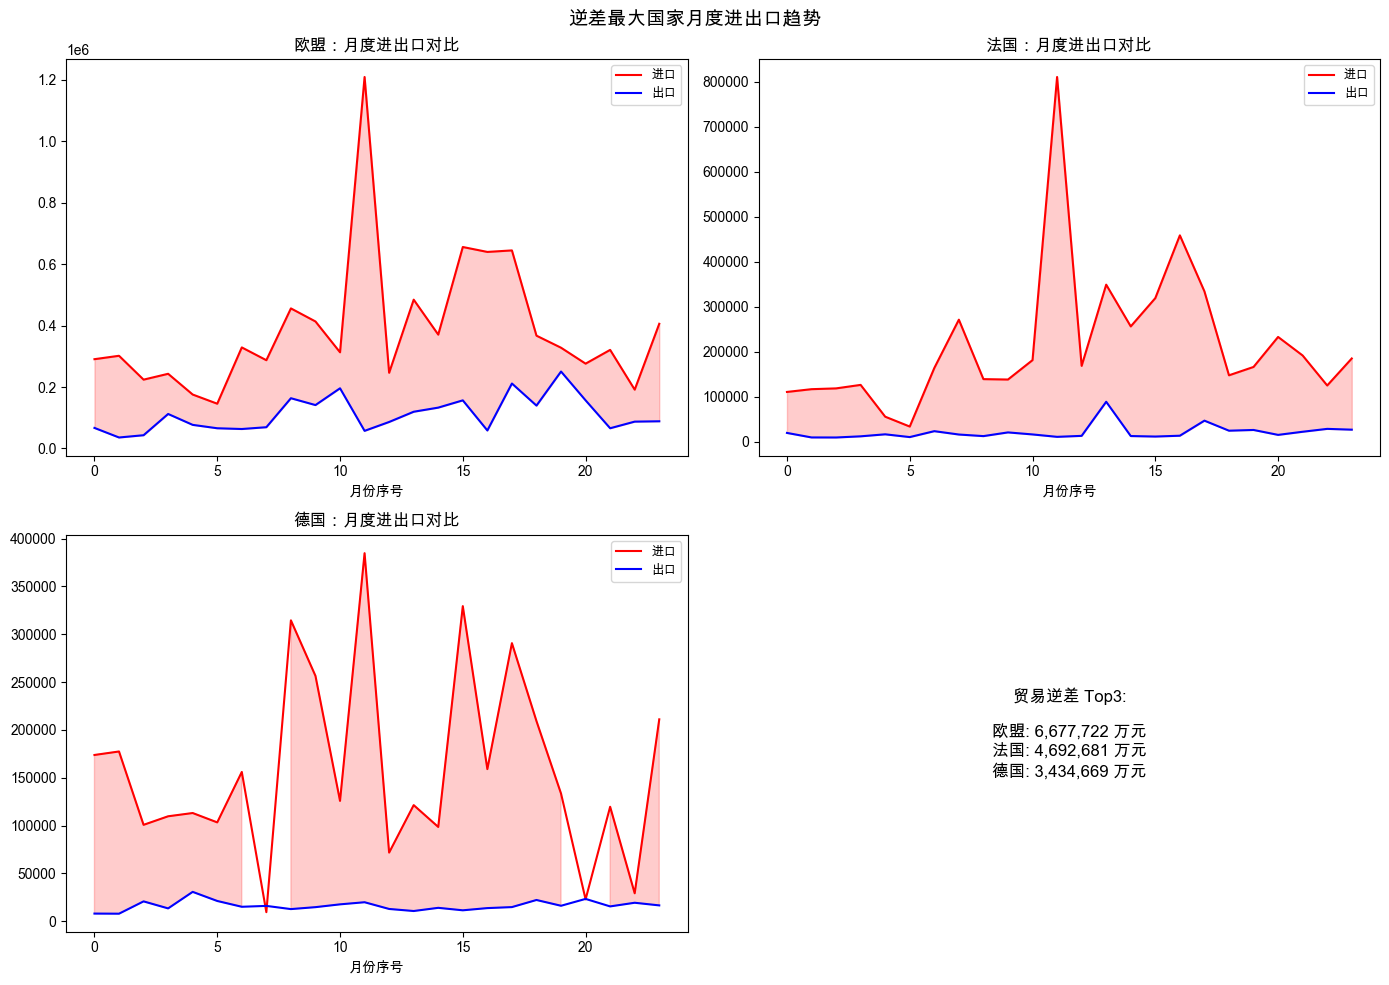

In [20]:
# Round 3：逆差 Top3 国家月度进出口对比
top3_deficit = top_deficit.index[:3].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flat

for idx, country in enumerate(top3_deficit):
    ax = axes_flat[idx]

    import_row = df_import[df_import['国家'] == country]
    export_row = df_export[df_export['国家'] == country]

    if len(import_row) > 0 and len(export_row) > 0:
        imp_vals = import_row[month_cols].values.flatten()
        exp_vals = export_row[month_cols].values.flatten()
        x = range(len(month_cols))

        ax.plot(x, imp_vals, 'r-', linewidth=1.5, label='进口')
        ax.plot(x, exp_vals, 'b-', linewidth=1.5, label='出口')
        ax.fill_between(x, imp_vals, exp_vals, alpha=0.2, color='red',
                       where=[i > e for i, e in zip(imp_vals, exp_vals)])
        ax.set_title(f'{country}：月度进出口对比')
        ax.legend(fontsize=9)
        ax.set_xlabel('月份序号')

# 第4个子图放总结
axes_flat[3].text(0.5, 0.5,
    f"贸易逆差 Top3:\n\n" +
    "\n".join([f"{c}: {top_deficit.loc[c, '贸易差额']:,.0f} 万元" for c in top3_deficit]),
    ha='center', va='center', fontsize=12, transform=axes_flat[3].transAxes)
axes_flat[3].set_axis_off()

plt.suptitle('逆差最大国家月度进出口趋势', fontsize=14)
plt.tight_layout()
plt.savefig('../output/deficit_monthly.png', dpi=300, bbox_inches='tight')
plt.show()

### Prompt 迭代总结

| 轮次 | 核心改进 | AI 表现 |
|:----:|----------|---------|
| 1 | 基础计算：按国家汇总进出口差额 | 正确但缺可视化 |
| 2 | 加可视化：红蓝双色条形图 | 效果好，建议加零线后更清晰 |
| 3 | 深入分析：月度对比+差额填充 | 实现完整，Inline Edit 微调透明度 |

**关键心得**：三轮迭代的递进是"计算→可视化→深入洞察"，每轮在上一轮基础上增加一个维度。

## 思考题参考答案

### 1. AI 在哪些步骤帮助最大？哪些步骤仍需自己判断？

**AI 帮助大的**：语法实现（pandas API 调用、matplotlib 参数设置）、代码框架搭建、重复性操作（批量统计、循环绘图）。

**仍需自己判断的**：缺失值填充策略的选择（业务含义）、异常值是否真的"异常"（可能是真实的大额交易）、分析结论的解读（相关≠因果）、图表设计的表达意图。

### 2. 使用 Vibe Coding 前后的效率对比

保守估计：手写完成同样任务约需 2-3 小时（查 API 文档+调试+美化图表）；使用 Vibe Coding 约 40-60 分钟。主要节省在：记忆 API 参数、调试语法错误、图表美化细节。但 Prompt 设计和结果审查本身需要时间。

### 3. Diff 审查中发现的 AI 典型问题

- **遗漏缺失值处理**：AI 默认数据完整，不主动检查 NaN
- **列名假设不准**：AI 可能猜错列名格式，需要 @引用数据文件
- **边界情况忽略**：如全 NaN 列的 median 仍是 NaN、除零错误
- **规避方法**：始终用 @引用提供数据上下文；每次生成后按三步清单审查